# Aqyl Jol — CV Perception Layer (Day 3)

**YDL 2026 · Applied Deep Learning · Day 3 Lab ("Build Something with the Right Architecture")**

A miniature of the **computer-vision perception layer** of *Aqyl Jol* — an AI digital twin for urban transport &
municipal fleet decarbonization (Orynbassar et al., 2025; winner, Meta Llama Accelerator Track 3). Aqyl Jol reads
**vehicles** and **road condition** from camera imagery. We rebuild that with three CNN models, all trained/run
locally on Apple-Silicon **MPS** (no cloud needed — this is a summer-school build):

| # | Model | Task | Architecture | Output |
|---|-------|------|--------------|--------|
| 1 | **Road quality** | detect surface damage | YOLOv8 (detection) | typed boxes: pothole / crack / manhole |
| 2 | **Road condition** | classify weather | ResNet18 (transfer learning) | fog / rain / snow / sand |
| 3 | **Vehicles** | detect + type | YOLOv8 (detection) | typed boxes: car / bus / truck / … |

**Why CNN?** Images are grids → the right inductive bias is convolution (locality + translation invariance).
Two detectors (road damage, vehicles) draw **typed boxes**; one classifier tags the **weather**. Together they
are the Aqyl Jol perception layer: *what hazard is on the road* + *what the weather is* + *what vehicles are present*.

> Data we gathered: DAWN (1027 road images), a Road-Damage detection set (2009 images), and a driving clip.

## 1 · Road quality — surface-damage detection (YOLOv8)

The practical "is the road bad?" model. We fine-tuned **YOLOv8** on the Road-Damage dataset (pothole / crack /
manhole, 2009 images, ~1.7k train) on MPS. It draws a **typed box** around each hazard on a photo — the road-side
counterpart of the vehicle detector, and the direct analogue of Aqyl Jol's road-hazard perception.

*Training note:* ~12 epochs on MPS reached **mAP50 ≈ 0.40** (small cracks are genuinely hard; potholes/manholes
detect well). Good enough for a local demo; more epochs / a bigger backbone would push it higher.

classes  : {'0': 'pothole', '1': 'crack', '2': 'manhole'}
detections on the demo images: {'manhole': 2, 'pothole': 2}


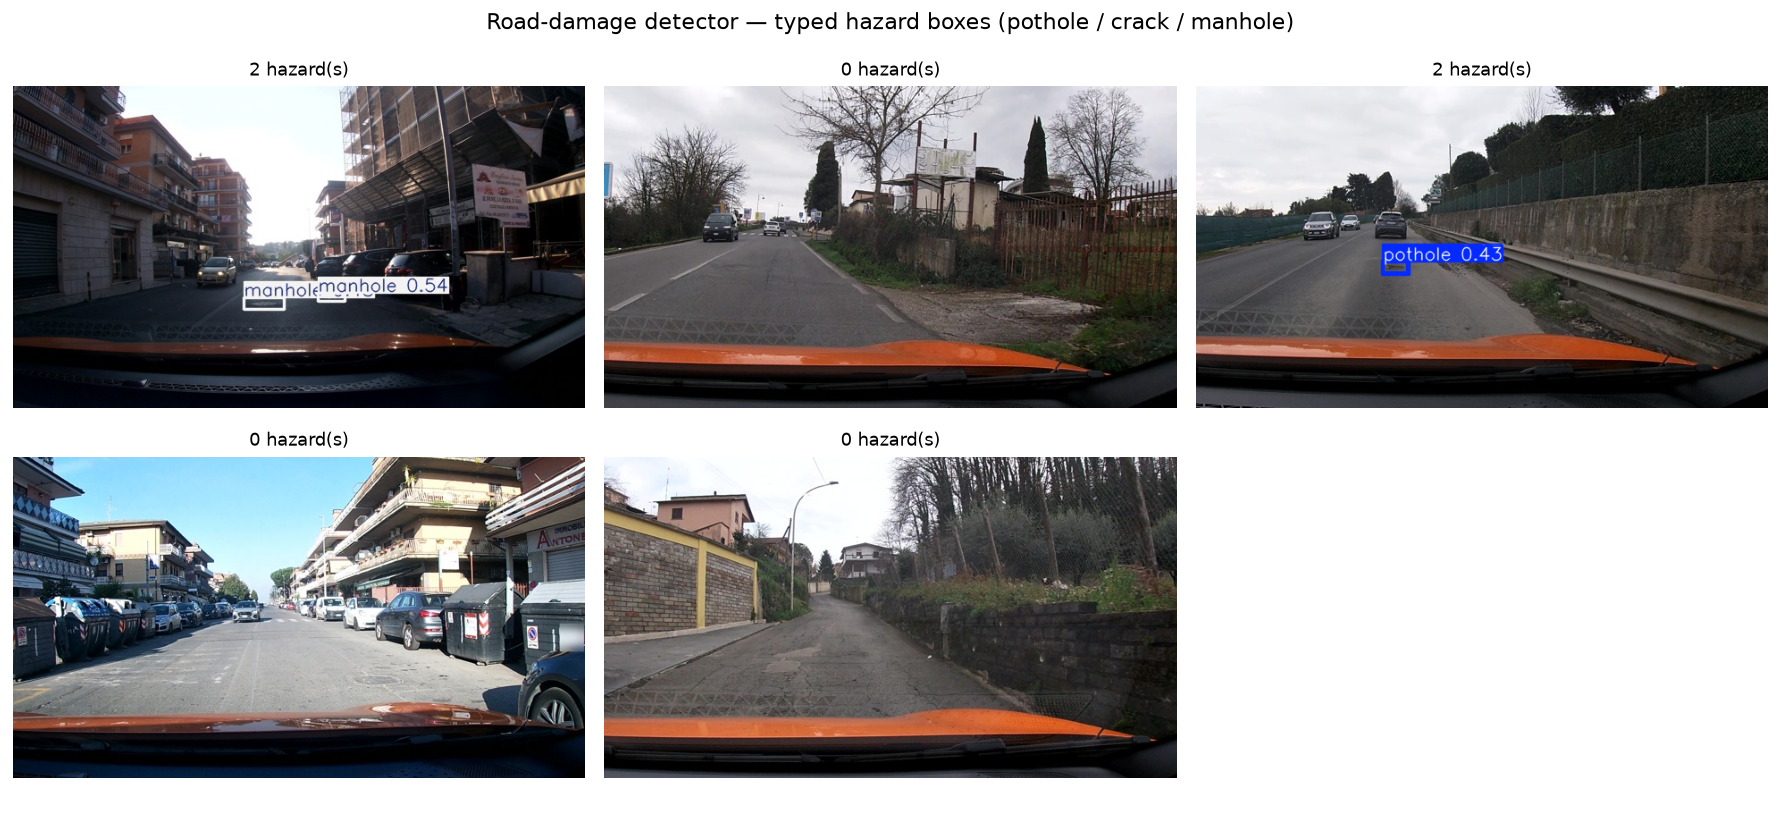

In [1]:
import json, os
from IPython.display import Image as IPImage
meta = json.load(open('artifacts/road_damage_meta.json'))
print('classes  :', meta['classes'])
print('detections on the demo images:', meta['demo_counts'])
IPImage(filename='artifacts/road_damage_detections.png')

## 2 · Road condition — weather classifier (ResNet18 transfer learning)

The environmental layer: **snow / rain / fog / sand** from DAWN (real adverse-weather road scenes). A pretrained
**ResNet18** with a frozen backbone and a fresh 4-class head — the Day-3 "own architecture on own data" piece.
(Mirrors Aqyl Jol's AstanaSnow/Flood/Ice; public data lacks flood/mud so weather classes stand in.)

Validation accuracy: 0.824

              precision    recall  f1-score   support

         fog      0.739     0.756     0.747        45
        rain      0.714     0.833     0.769        30
        sand      0.909     0.833     0.870        48
        snow      0.964     0.900     0.931        30

    accuracy                          0.824       153
   macro avg      0.832     0.831     0.829       153
weighted avg      0.832     0.824     0.826       153



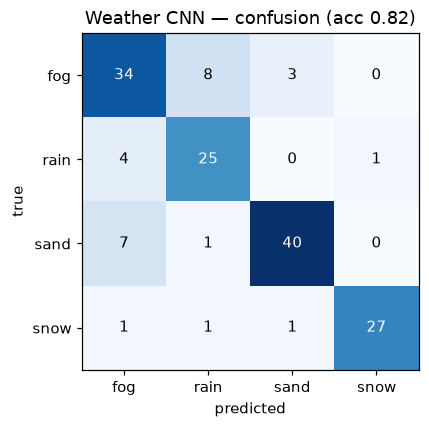

In [2]:
%matplotlib inline
import numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':110,'font.size':10})
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')

classes = json.load(open('data/road_meta.json'))['classes']
norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
eval_tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), norm])
val_ds = datasets.ImageFolder('data/split/val', eval_tf)
model = resnet18(); model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load('data/road_resnet18.pt', map_location=DEVICE)['state_dict'])
model.eval().to(DEVICE)

preds, gts = [], []
with torch.no_grad():
    for xb, yb in DataLoader(val_ds, batch_size=32, num_workers=0):
        preds += model(xb.to(DEVICE)).argmax(1).cpu().tolist(); gts += yb.tolist()
acc = float(np.mean(np.array(preds)==np.array(gts)))
print(f'Validation accuracy: {acc:.3f}\n')
print(classification_report(gts, preds, target_names=classes, digits=3))
cm = confusion_matrix(gts, preds)
plt.figure(figsize=(4.6,4)); plt.imshow(cm, cmap='Blues')
plt.xticks(range(len(classes)), classes); plt.yticks(range(len(classes)), classes)
plt.xlabel('predicted'); plt.ylabel('true'); plt.title(f'Weather CNN — confusion (acc {acc:.2f})')
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

**Grad-CAM** — the classifier attends to road surface / sky / weather texture, not frame borders (bottom row =
attention; last two panels are confident mistakes).

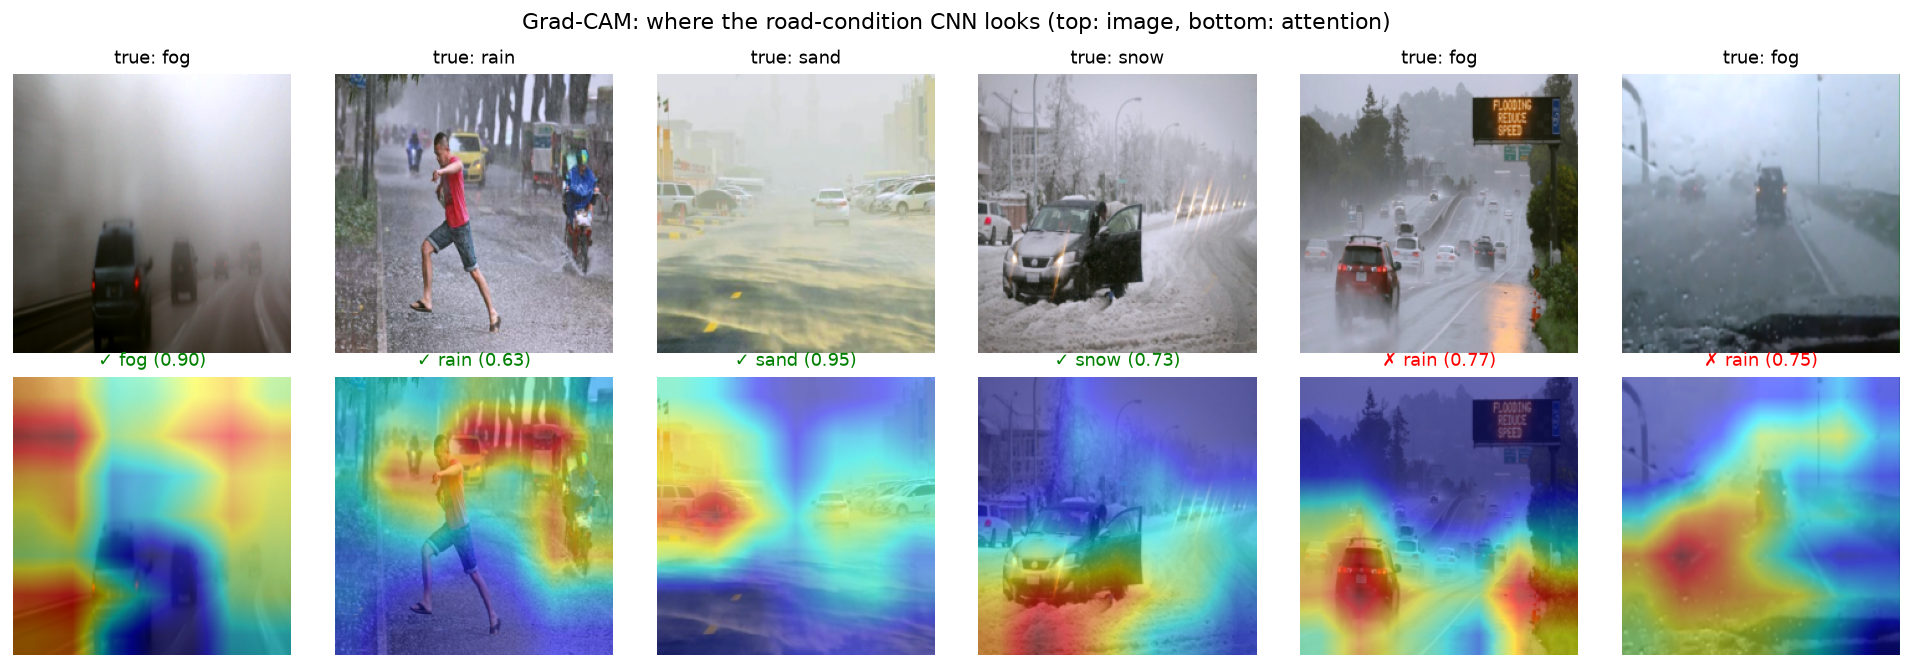

In [3]:
IPImage(filename='artifacts/road_gradcam.png')

## 3 · Vehicles — detection on video (pretrained YOLOv8)

COCO-pretrained **YOLOv8** on a driving clip: typed boxes on car / bus / bicycle **in motion**, plus throughput
(Aqyl Jol reports 60–125 FPS; we run on a laptop MPS).

throughput : 49.8 FPS on mps  (647 frames)
detections : {'car': 75, 'bicycle': 57, 'bus': 1}


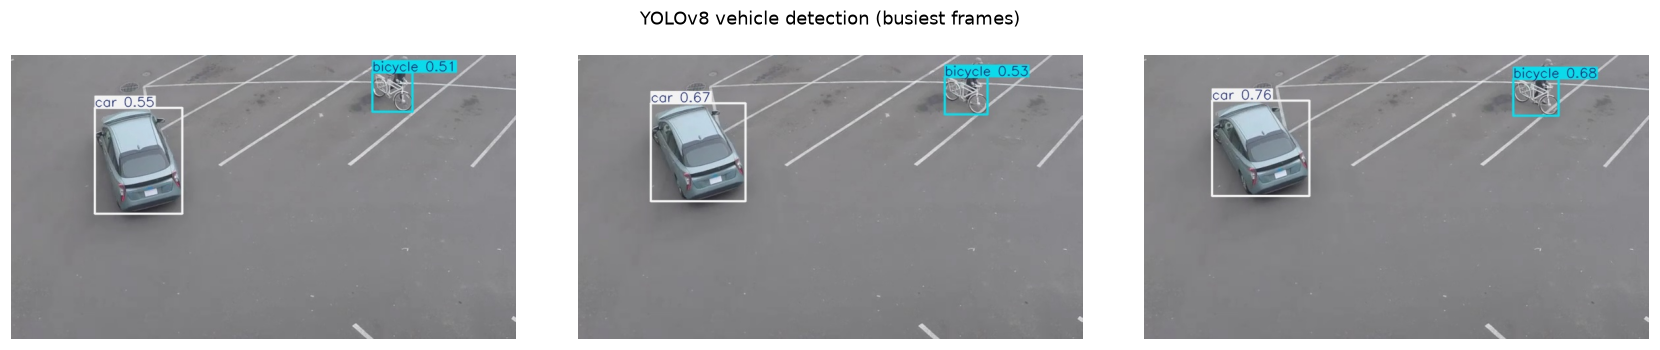


Full annotated video -> artifacts/traffic_detected.mp4


In [4]:
m = json.load(open('artifacts/yolo_metrics.json'))
print(f"throughput : {m['fps']} FPS on {m['device']}  ({m['frames']} frames)")
print(f"detections : {m['counts']}")
stills = [f'artifacts/traffic_frame_{i}.jpg' for i in range(3) if os.path.exists(f'artifacts/traffic_frame_{i}.jpg')]
fig, axes = plt.subplots(1, len(stills), figsize=(5.2*len(stills), 3.2))
if len(stills) == 1: axes = [axes]
for ax, s in zip(axes, stills):
    ax.imshow(plt.imread(s)); ax.axis('off')
fig.suptitle('YOLOv8 vehicle detection (busiest frames)', fontsize=12)
plt.tight_layout(); plt.show()
print('\nFull annotated video -> artifacts/traffic_detected.mp4')

## The combined perception layer & findings

Three CNNs = the Aqyl Jol CV layer in miniature: a road photo → **damage boxes** (pothole/crack/manhole) +
**weather** tag; a traffic video → **vehicle** boxes. In the full system these feed the causal fleet model and the
iOS app.

**Findings**
- **Road damage (YOLOv8):** detects potholes/manholes with typed boxes at mAP50 ≈ 0.40 (~12 epochs, MPS). This is
  the "проверка качества дороги" — the model marks *where* and *what* the hazard is.
- **Weather (ResNet18):** ~0.82 val accuracy from a frozen backbone; snow/sand easiest, fog↔rain most confused.
- **Grad-CAM** confirms the weather model looks at real road/sky cues.
- **Vehicles (YOLOv8):** real-time on a laptop MPS, typed boxes on moving vehicles.

**Limitations & next steps (local, no production)**
- Public data lacks true flood/mud/ice ground-level sets; DAWN weather + road-damage cover most of the hazard list.
- Road-damage training stopped early (~12 epochs) due to a disk-cache quirk; a clean run / larger model raises mAP.
- Vehicle detector is pretrained COCO; Aqyl Jol fine-tunes on 14k Astana images across 23 classes and uses
  segmentation for road state. Natural next step: fine-tune both and add per-pixel road segmentation.